RUNNING EDA ON CREDIT TRANSACTION DATA FROM KAGGLE: https://www.kaggle.com/competitions/ieee-fraud-detection 

Merging transaction and identity data by the transaction ID. 
<br>
The identity dataset holds extra info on certain transactions. Information such as device type, browser type, phone type, other technical fingerprint stuff. Some labels are hidden due to security.

In [1]:
import pandas as pd
import numpy as np

train_tx = pd.read_csv('data/train/train_transaction.csv')
train_id = pd.read_csv('data/train/train_identity.csv')

train = train_tx.merge(train_id, on='TransactionID', how='left')
train.shape
train.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Check the columns and their data types:

In [2]:
train.info()

train.dtypes.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


float64    399
object      31
int64        4
Name: count, dtype: int64

Unique elements in the dataset:

In [3]:
train.nunique()

TransactionID     590540
isFraud                2
TransactionDT     573349
TransactionAmt     20902
ProductCD              5
                   ...  
id_36                  2
id_37                  2
id_38                  2
DeviceType             2
DeviceInfo          1786
Length: 434, dtype: int64

Summary of the dataset:

In [4]:
train.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


Are there any missing values in the dataset?

In [5]:
train.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
id_36             449555
id_37             449555
id_38             449555
DeviceType        449730
DeviceInfo        471874
Length: 434, dtype: int64

Check the target 

In [6]:
train['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

TARGET: <br>
Approx 96.5% is not fraud <br>
Approx 3.4% is fraud

Is fraud detected on higher og lower transaction amounts?
<br>

We see that fraud transactions are slightly higher on average. If we look at the max, fraud transactions are way lower. Transaction amount by itself is not enough to call out fraud.

In [7]:
train.groupby('isFraud')['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


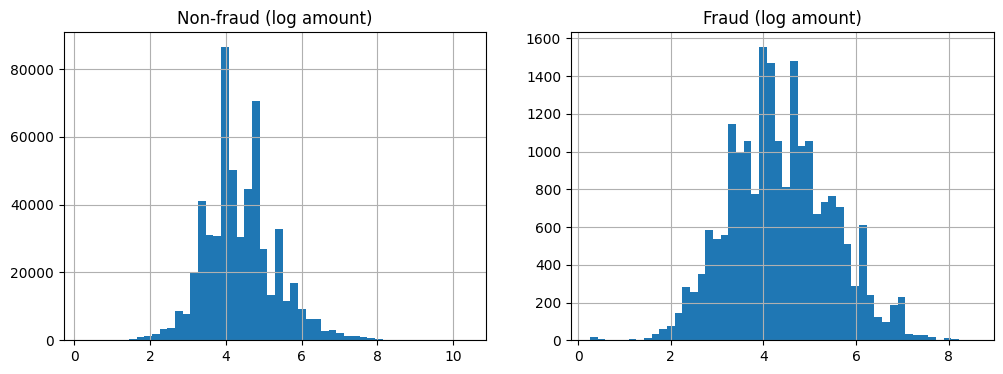

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,4))
np.log1p(train[train['isFraud']==0]['TransactionAmt']).hist(bins=50, ax=ax[0])
ax[0].set_title('Non-fraud (log amount)')
np.log1p(train[train['isFraud']==1]['TransactionAmt']).hist(bins=50, ax=ax[1])
ax[1].set_title('Fraud (log amount)')
plt.show()

Fraud rate by ProductDC (product code)
<br>
IS FRUAD: <br>
C = 11.6%
S = 5.8%
H = 4.7%
R = 3.7%
W = 20.3%

In [9]:
train.groupby('ProductCD')['isFraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
ProductCD,,
C,0.116873,68519
S,0.058996,11628
H,0.047662,33024
R,0.037826,37699
W,0.020399,439670


Fraud rate by card type <br>

IS FRAUD: <br>
credit = 6.6%
debit = 2.4%

In [10]:
train.groupby('card4')['isFraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)

train.groupby('card6')['isFraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
card6,,
credit,0.066785,148986
debit,0.024263,439938
charge card,0.000000,15
debit or credit,0.000000,30


Fraud rate by email domain <br>

IS FRAUD: <br>
outlook = 9.4%
hotmail = 5.2%
gmail = 4.3%


In [11]:
top_domains = train['P_emaildomain'].value_counts().head(15).index
train[train['P_emaildomain'].isin(top_domains)].groupby('P_emaildomain')['isFraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
P_emaildomain,,
outlook.com,0.094584,5096
hotmail.com,0.052950,45250
gmail.com,0.043542,228355
icloud.com,0.031434,6267
comcast.net,0.031187,7888
bellsouth.net,0.027763,1909
live.com,0.027622,3041
anonymous.com,0.023217,36998
yahoo.com,0.022757,100934


Fraud rate by DeviceType

In [12]:
train.groupby('DeviceType')['isFraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
DeviceType,,
mobile,0.101662,55645
desktop,0.065215,85165


Does the fraud rate have different trend over the time range? <br>
The data is from a limited period of time (seconds).

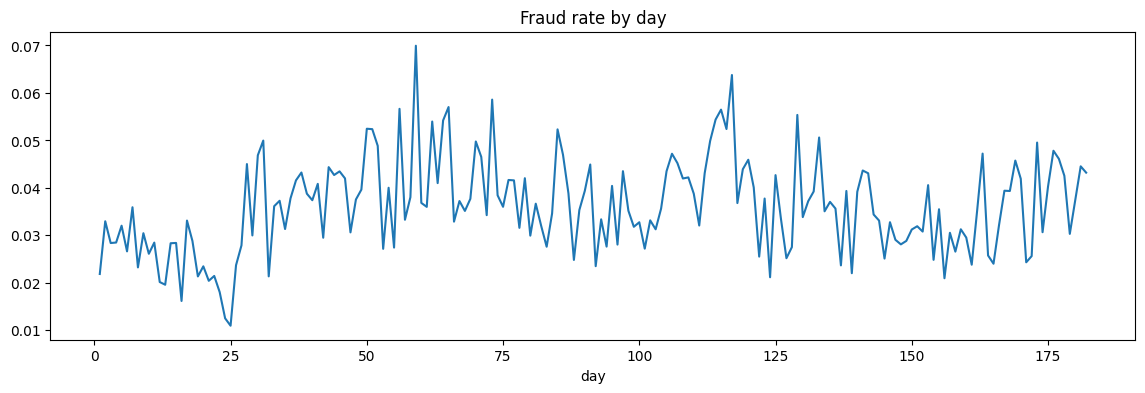

In [13]:
train['day'] = train['TransactionDT'] // (24*60*60)
train.groupby('day')['isFraud'].mean().plot(figsize=(14,4), title='Fraud rate by day')
plt.show()

Finding the correlation between isFraud and all other columns except non numerical columns. <br>

In [14]:
train.select_dtypes(include=[np.number]).corrwith(train['isFraud']).sort_values(ascending=False)

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
             ...   
V49       -0.110920
V48       -0.115786
id_01     -0.120099
D7        -0.127199
D8        -0.142636
Length: 404, dtype: float64

Create EDA report

In [ ]:
from data_profiling import ProfileReport

profile = ProfileReport(train,title="Fraud detection")
profile.to_file("eda_report.html")

c:\Users\Bruker\Desktop\fraud-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Summarize dataset:   0%|          | 2/440 [00:03<07:21,  1.01s/it, Describe variable: C5]   